In [12]:
!pip install nc_time_axis

Defaulting to user installation because normal site-packages is not writeable


In [22]:
# load netcdf from OM4 runs

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import xarray as xr
from matplotlib.colorbar import ColorbarBase
import cftime
# Library for working with tar files
import tarfile
import glob 
import cftime
import nc_time_axis

BASE = '/orcd/data/abodner/002/shared_datasets/'

In [23]:
# Unpack .tar files (only need to run this once)
# "file_list" is the list of .tar files to be unpacked
# "save_path" is the directory where unpacked .nc files will be saved

'''
def unpack_tar(file_list, save_path):
    for tar_file_name in file_list:
        tar = tarfile.open(tar_file_name)
        tar.extractall(path=save_path)
        tar.close()
        
        
# extract netcdf files from .tar

file_list = glob.glob(BASE+'thetaoga/tar_files/*_thetaoga.tar')
save_path = BASE+'om4_output/'

unpack_tar(file_list, save_path)
print('Done!')
'''

"\ndef unpack_tar(file_list, save_path):\n    for tar_file_name in file_list:\n        tar = tarfile.open(tar_file_name)\n        tar.extractall(path=save_path)\n        tar.close()\n        \n        \n# extract netcdf files from .tar\n\nfile_list = glob.glob(BASE+'thetaoga/tar_files/*_thetaoga.tar')\nsave_path = BASE+'om4_output/'\n\nunpack_tar(file_list, save_path)\nprint('Done!')\n"

In [24]:
# global temperature data from all models

### OM4 ###
# path to dataset
PATH_GFDL = BASE+'om4_output/new_runs/'

# load BFF11 data 
globT_GFDL_BFF11 = xr.open_mfdataset(PATH_GFDL+'BFF11/*thetaoga.nc')  

# load BOD23 data 
globT_GFDL_BOD23 = xr.open_mfdataset(PATH_GFDL+'BOD23/*thetaoga.nc')  

# load BOD23 data 
globT_GFDL_noMLE = xr.open_mfdataset(PATH_GFDL+'noMLE/*thetaoga.nc')  

# load BOD23 data tuned to match global temp
#globT_GFDL_BOD23_tuned = xr.open_mfdataset(PATH_GFDL+'thetaoga/265/*.nc')  


### BLOM ###
# path to dataset
PATH_BLOM = BASE+'blom_output/new_files/'
# load BFF11 data 
globT_BLOM_BFF11 = xr.open_dataset(PATH_BLOM+'N2NOIIAJRA20TR_TL319_tn14_Bodner01_Tavg_v2.nc')  

# load BOD23 data 
globT_BLOM_BOD23 = xr.open_dataset(PATH_BLOM+'N2NOIIAJRA20TR_TL319_tn14_Bodner02_Tavg_v2.nc')  

# load BOD23 data tuned 
globT_BLOM_BOD23_tuned = xr.open_dataset(PATH_BLOM+'N2NOIIAJRA20TR_TL319_tn14_Bodner03_Tavg_v2.nc')  


### CESM ###
# path to dataset
PATH_CESM = BASE+'cesm_output/'
# load BOD23 data 
globT_CESM_BOD23_tuned = xr.open_dataset(PATH_CESM+'049_BOD23_Cr_v8/ncfiles/g.e30_a06a.GJRAv4.TL319_t232_wgx3_hycom1_N75.2025.049_mon_ave_global_means.nc') 

# load BFF11 data tuned 
globT_CESM_BFF11 = xr.open_dataset(PATH_CESM+'051_BFF11_Lf_1km/ncfiles/g.e30_a06a.GJRAv4.TL319_t232_wgx3_hycom1_N75.2025.051_mon_ave_global_means.nc')

# load BFF11 
#globT_CESM_BFF11_Li2016 = xr.open_dataset(PATH_CESM+'045_BFF11_Li16/ncfiles/g.e30_b05.GJRAv4.TL319_t232_wgx3_hycom1_N75.2025.045_mon_ave_global_means.nc')


/tmp/ipykernel_3605/2717285805.py:8: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  globT_GFDL_BFF11 = xr.open_mfdataset(PATH_GFDL+'BFF11/*thetaoga.nc')
/tmp/ipykernel_3605/2717285805.py:8: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  globT_GFDL_BFF11 = xr.open_mfdataset(PATH_GFDL+'BFF11/*thetaoga.nc')
/tmp/ipykernel_3605/2717285805.py:8: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  globT_GFDL_BFF11 = xr.open_mfdataset(PATH_GFDL+'BFF11/*thetaoga.nc')
/tmp/ipykernel_3605/2717285805.py:8: FutureWarning: In a future version of xarray 

In [25]:
time_ax = np.arange(1958,2023,1)
globT_BLOM_BFF11_shifted = np.zeros(len(time_ax))
globT_BLOM_BFF11_shifted[:] = np.nan
globT_BLOM_BFF11_shifted[3:] = globT_BLOM_BFF11.Tavg.groupby('time.year').mean().values
globT_BLOM_BOD23_tuned_shifted = np.zeros(len(time_ax))
globT_BLOM_BOD23_tuned_shifted[:] = np.nan
globT_BLOM_BOD23_tuned_shifted[3:] = globT_BLOM_BOD23_tuned.Tavg.groupby('time.year').mean().values

## plot thetaoga timeseries

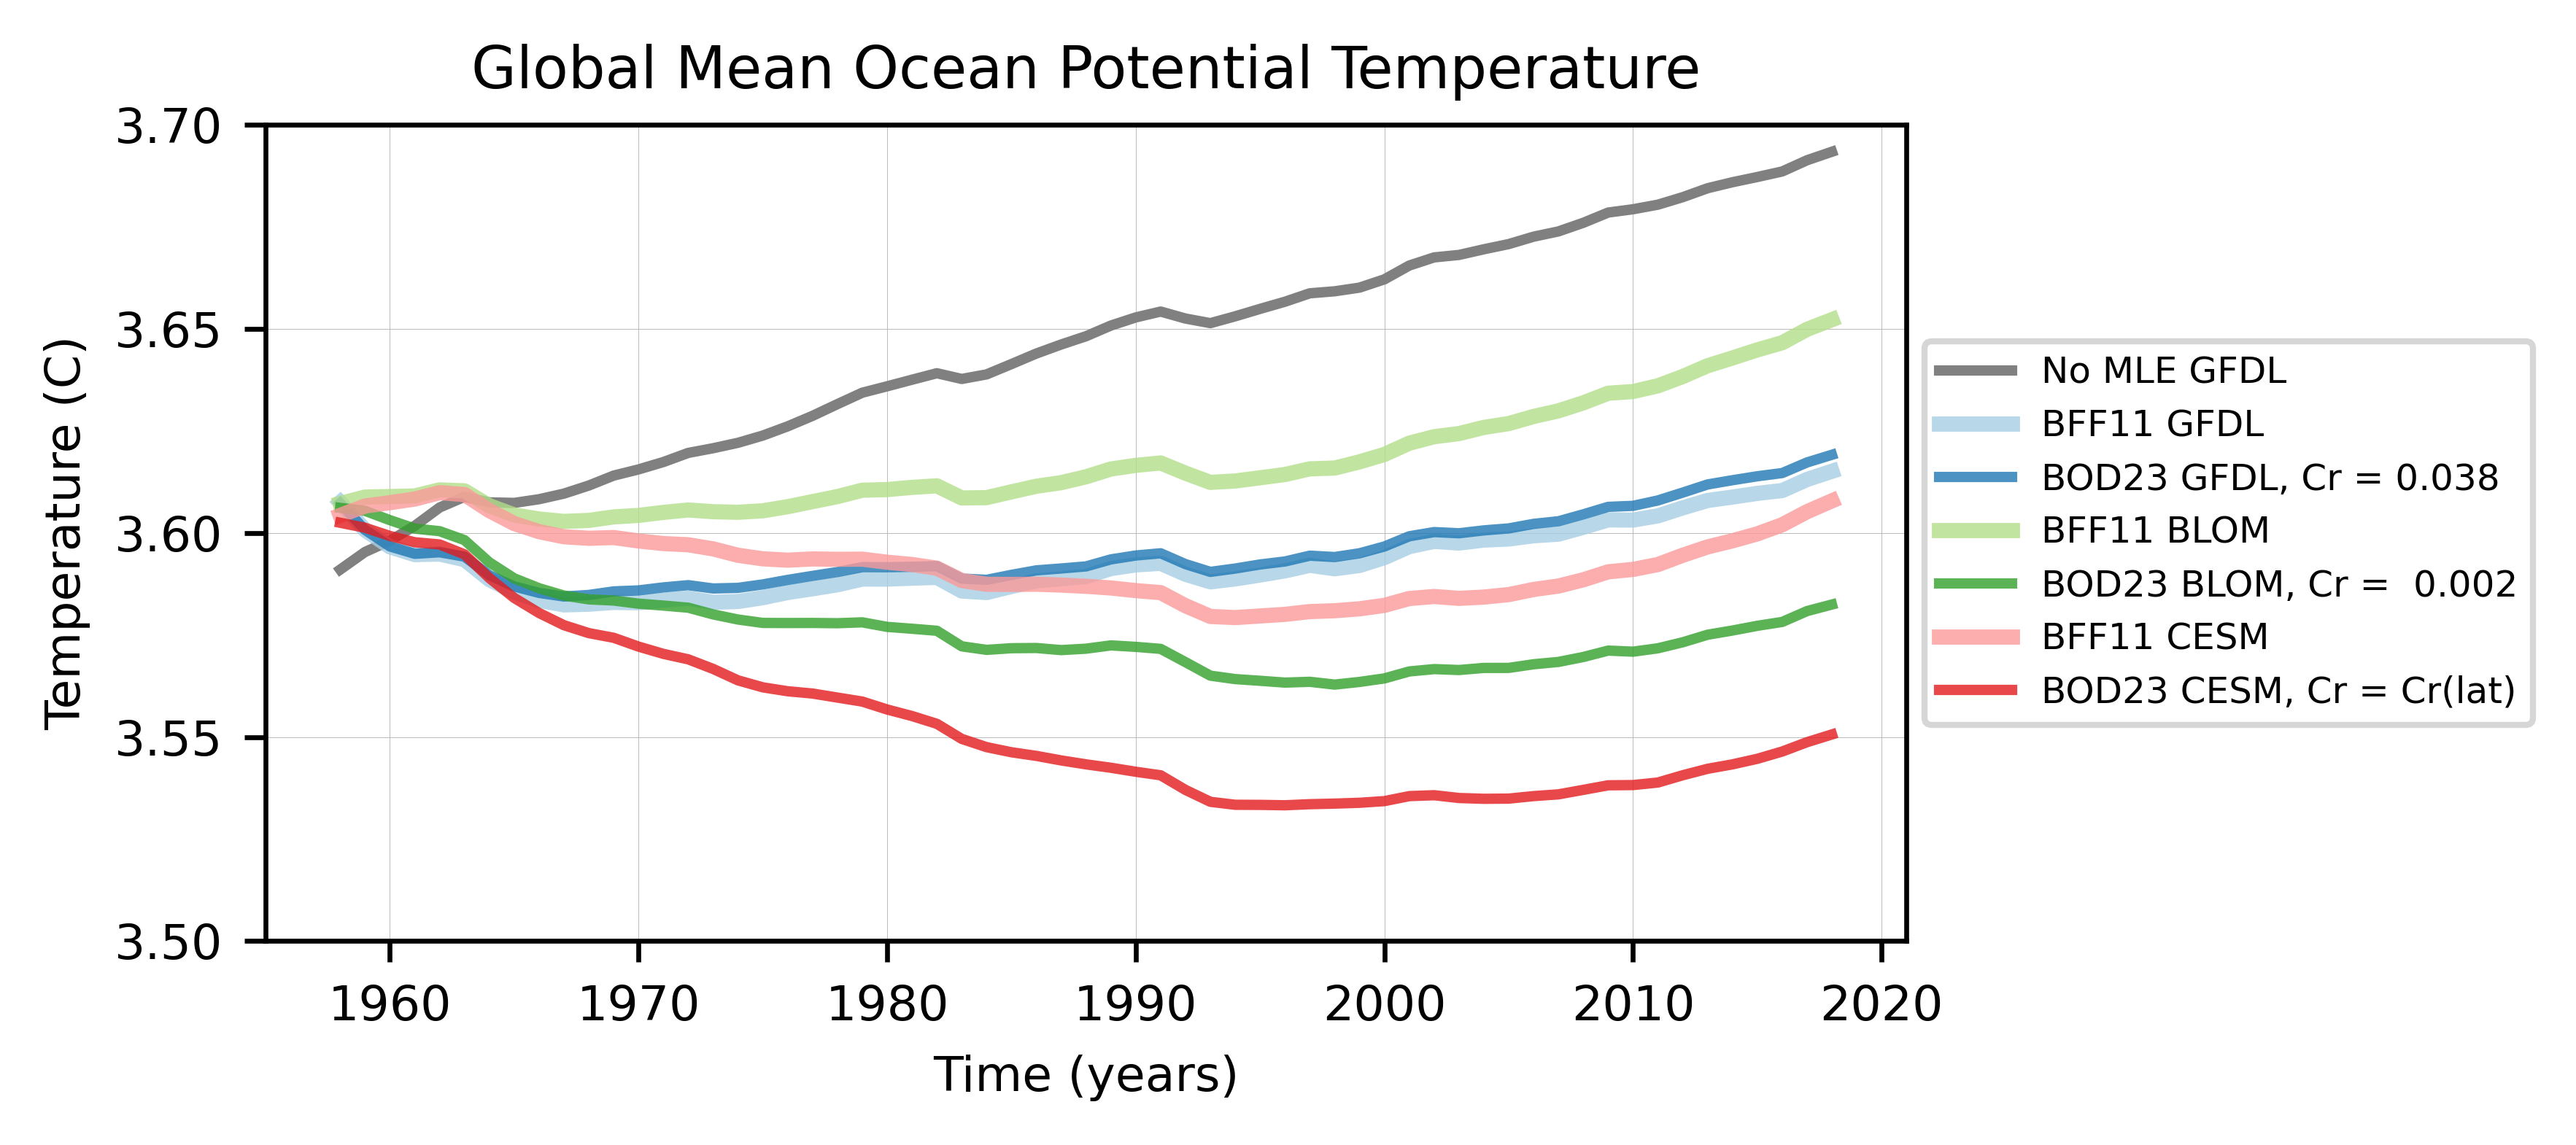

In [26]:
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(7, 5), dpi=600)
fig.tight_layout(pad=13.0)



time_ax = np.arange(1958,2019,1)
#globT_BLOM_BFF11_shifted = np.zeros(len(time_ax))
#globT_BLOM_BFF11_shifted[:] = np.nan
#globT_BLOM_BFF11_shifted[:-3] = globT_BLOM_BFF11.Tavg.groupby('time.year').mean().values
#globT_BLOM_BOD23_tuned_shifted = np.zeros(len(time_ax))
#globT_BLOM_BOD23_tuned_shifted[:] = np.nan
#globT_BLOM_BOD23_tuned_shifted[:-3] = globT_BLOM_BOD23_tuned.Tavg.groupby('time.year').mean().values
#globT_BLOM_BOD23_shifted = np.zeros(len(time_ax))
#globT_BLOM_BOD23_shifted[:] = np.nan
#globT_BLOM_BOD23_shifted[:-3] = globT_BLOM_BOD23.Tavg.groupby('time.year').mean().values


import matplotlib.pyplot as pl
colors = pl.cm.Paired(np.linspace(0,1,12))
plt.plot(time_ax,globT_GFDL_noMLE.thetaoga.values[:len(time_ax)],color='grey',label='No MLE GFDL',linewidth =1.7)
plt.plot(time_ax,globT_GFDL_BFF11.thetaoga.values[:len(time_ax)],color=colors[0],label='BFF11 GFDL',linewidth =2.5,alpha=0.8)
#plt.plot(time_ax,globT_GFDL_BOD23_tuned.thetaoga.values[:len(time_ax)],color=colors[1],label='BOD23 GFDL, Cr = 0.038',linewidth =1.7)
plt.plot(time_ax,globT_GFDL_BOD23.thetaoga.values[:len(time_ax)],color=colors[1],label='BOD23 GFDL, Cr = 0.038',linewidth =1.7,alpha=0.8)


plt.plot(time_ax,globT_BLOM_BFF11.Tavg.groupby('time.year').mean().values[:len(time_ax)],color=colors[2], label='BFF11 BLOM',linewidth =2.5,alpha=0.8)
#plt.plot(time_ax,globT_BLOM_BOD23_tuned.Tavg.groupby('time.year').mean().values[:len(time_ax)],color=colors[3],label='BOD23 BLOM, Cr = 0.02',linewidth =1.7)
plt.plot(time_ax,globT_BLOM_BOD23.Tavg.groupby('time.year').mean().values[:len(time_ax)],color=colors[3],label='BOD23 BLOM, Cr =  0.002',linewidth =1.7,alpha=0.8)

plt.plot(time_ax,globT_CESM_BFF11.thetaoga.groupby('time.year').mean().values[:len(time_ax)], color=colors[4],label='BFF11 CESM',linewidth =2.5,alpha=0.8)
#plt.plot(time_ax,globT_CESM_BFF11_Li2016.thetaoga.groupby('time.year').mean().values[:len(time_ax)],color=colors[6],label='BFF11 Li16 CESM',linewidth =1.7)
plt.plot(time_ax,globT_CESM_BOD23_tuned.thetaoga.groupby('time.year').mean().values[:len(time_ax)],color=colors[5],label='BOD23 CESM, Cr = Cr(lat)',linewidth =1.7,alpha=0.8)

#globT_BLOM_BFF11.shift(time=300).Tavg.plot(label='BFF11 BLOM', linewidth =2)
#globT_CESM_BFF11.shift(time=1958).thetaoga.plot(label='BFF11 CESM', linewidth =2)

#globT_OM4_BOD23.thetaoga.plot(label='BOD23 GFDL', linewidth =2)
#globT_BLOM_BOD23.Tavg.plot(label='BOD23 BLOM',linewidth =2)

#globT_GFDL_BOD23_tuned.thetaoga.plot(label='BOD23 GFDL', linewidth =2)
#globT_BLOM_BOD23_tuned.shift(time=300).Tavg.plot(label='BOD23 BLOM',linewidth =2)
#globT_CESM_BOD23_tuned.shift(1958, "Y").thetaoga.plot(label='BOD23 CESM',linewidth =2)

plt.grid(linewidth=.1)
plt.legend(fontsize=6,loc='center left', bbox_to_anchor=(1, 0.5))
plt.ylim([3.5,3.7])
plt.xlabel('Time (years)')
plt.ylabel('Temperature (C)')
plt.title('Global Mean Ocean Potential Temperature')

plt.rcParams.update({'font.size': 8})
# save figure
plt.savefig('./figures/thetaoga_noMLE')